# Zero-shot with the cell-cell communication

# Introduction

Because we use the pair-wise training strategy, the results show that the gene expression profile can partially indicates the spatial locations assisting by the cellular proximity information. Here, we want to investigate the performance of our model, and the biological insight it can provide. Furthermore, we can dive into the interpretation of the model, aiming to make nice interpretation and reveal the real biology happen in the tissue.

For a certain cell, they have the neighbors. We want to test whether they can accurately reveal the cellular composition.
1. we need to pre-calculate the cellular composition, including cell types and cell neighbors.  
    - 1 vs 1: whether two cells are proximity of each other (zero-shot prediction)
    - 1 vs n: whether model can find the further distance  
    - n vs n: whether the model can figure out the cell type composition in the niche  
2. The cell neighbor should be devided into many different distance.
3. Cell types composition should be test independently
4. A fine-tuning module should be developed
5. We also need to calculate the zero-shot cell neighbot prediction power


# Visualizing the zero-shot results of the neighborhoods predictions

- The results was ran under the certain scripts "/Spatialformer/fine_tune.py"  
python fine_tune.py 
- Experimental setup only on one slide: THD0008
- Using k=3 to do the cross validation if running in the fine-tune mode
- the distance of the radius increases from 20 to 100 with 5 data points [10, 20, 30, 50, 80, 100, 120]

In [1]:
#loading the dataframe
import pandas as pd
stats = pd.read_csv("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/results/THD0008_zero_shot_all_values.csv", index_col=0)
stats_allslides = pd.read_csv("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/results/THD0008_zero_shot_all_allslidesfinetuned.csv", index_col=0)
stats_alllung = pd.read_csv("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/results/THD0008_zero_shot_all_lungslidespretrained.csv", index_col=0)



In [2]:
stats

,test_accuracy,test_recall,test_precision,test_specificity,test_f1,radius
0,0.660221,0.718232,0.643564,0.602210,0.678851,10
1,0.622736,0.636322,0.619489,0.609149,0.627793,20
2,0.604827,0.585187,0.609113,0.624468,0.596910,30
3,0.589470,0.553984,0.596305,0.624956,0.574366,50
4,0.558065,0.514472,0.563611,0.601657,0.537922,80
5,0.552410,0.491937,0.559620,0.612882,0.523601,100
6,0.553318,0.497321,0.560043,0.609315,0.526822,120


In [3]:
stats["Model"] = "Fine_tune(one slide)"

In [4]:
stats_allslides["Model"] = "Zero_shot(61 slides)"


In [5]:
stats_alllung["Model"] = "Fine_tune(lung slides)"

In [6]:
all_stats = pd.concat([stats, stats_allslides, stats_alllung])

In [7]:
all_stats["Model"].unique()

array(['Fine_tune(one slide)', 'Zero_shot(61 slides)',
       'Fine_tune(lung slides)'], dtype=object)

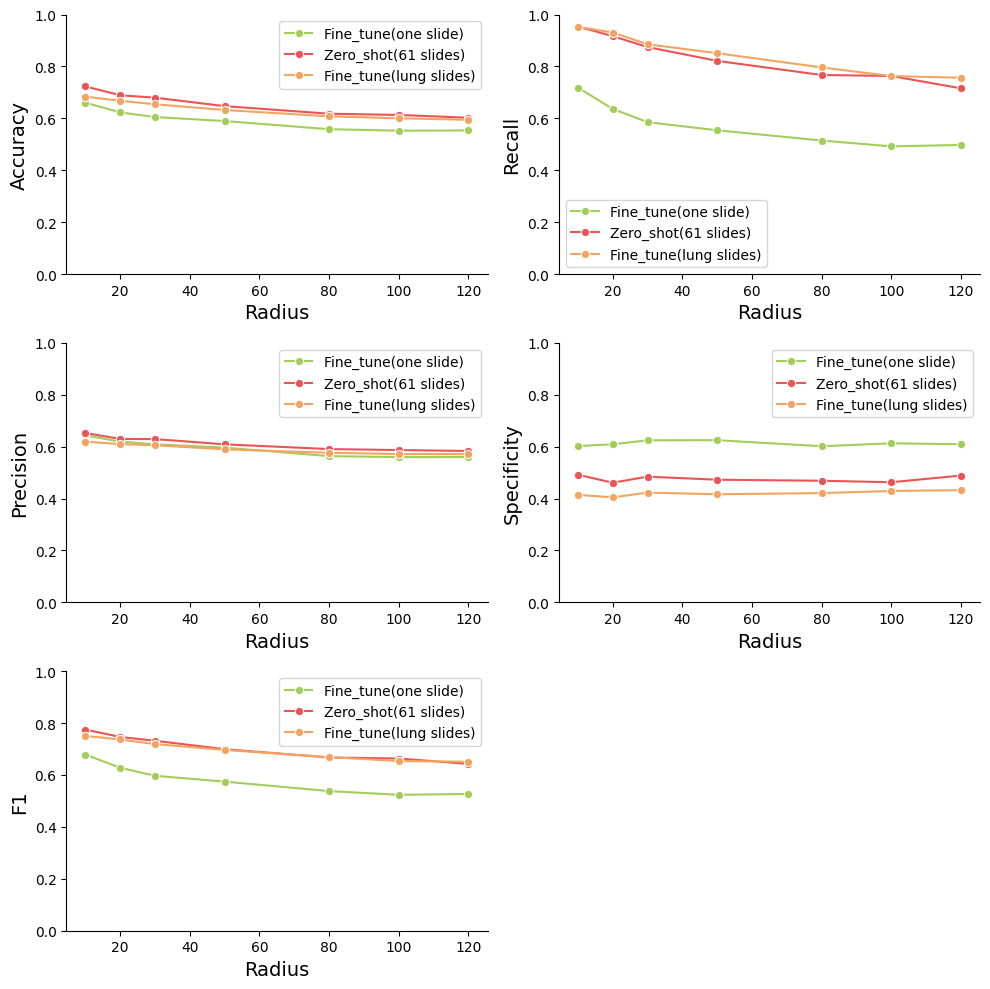

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10))  # Adjusted figsize for better visibility
dot_color = ["#A2CD5A", "#EB5354", "#F4A460"]

# Flatten axes array for easy iteration
axes = axes.flatten()
metrics = ["test_accuracy", "test_recall", "test_precision", "test_specificity", "test_f1"]

# Loop through metrics to create individual plots
for ax, metric in zip(axes, metrics):
    sns.lineplot(data=all_stats, x='radius', y=metric, marker='o', ax=ax, linewidth=1.5, hue='Model', palette=dot_color)
    ax.set_ylabel(f'{metric.split("_")[1].capitalize()}', fontsize=14, color='black')  # Set the y-axis label color to black
    ax.set_xlabel('Radius', fontsize=14, color='black')  # Set the x-axis label color to black
    ax.tick_params(axis='x', colors='black')  # Set the x-axis tick colors to black
    ax.tick_params(axis='y', colors='black')  # Set the y-axis tick colors to black
    ax.grid(False)
    ax.set_ylim(0.0, 1.0)
    ax.legend()

# Adjust the legend position
# plt.legend(title='Model', loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3)  # Adjusts legend position
# Create a single legend
# handles, labels = axes[0].get_legend_handles_labels()  # Get handles and labels from the first subplot
# plt.legend(handles, labels, title='Model', loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3)  # Add a single legend

# Hide any unused axes
for i in range(len(metrics), len(axes)):
    axes[i].set_visible(False)

# Remove spines for a cleaner look
sns.despine(top=True, right=True)

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig("/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/figures/radius_metrics.png", dpi=300)

# Show the plot
plt.show()

Testing the generalisation performance across
- Different assays: Xenium and MERFISH
- Variant tissue types: Lung, Colon, Breast

In [2]:
#zero-shot datasets loading for MERFISH
Mf_Breast = pd.read_csv("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/results/MERFISH_Breast_zero_shot_mean_values_per_radius.csv", index_col=0)
Mf_Lung = pd.read_csv("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/results/MERFISH_Lung_zero_shot_mean_values_per_radius.csv", index_col=0)
Mf_Colon = pd.read_csv("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/results/MERFISH_Colon_zero_shot_mean_values_per_radius.csv", index_col=0)

#zero-shot datasets loading for Xenium
Xe_CRC = pd.read_csv("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/results/Xenium_CRC_zero_shot_mean_values_per_radius.csv", index_col=0)
Xe_Lung = pd.read_csv("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/results/THD0008_zero_shot_all_values.csv", index_col=-1)
Xe_Breast = pd.read_csv("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/results/breast_cancer_zero_shot_mean_values_per_radius.csv", index_col=0)

#few-shot datasets (10k) loading for MERFISH
Mf_Breast_few_10k = pd.read_csv("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/results/MERFISH_Breast_zero_shot_mean_values_per_radius_10000.csv", index_col=0)
Mf_Lung_few_10k = pd.read_csv("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/results/MERFISH_Lung_zero_shot_mean_values_per_radius_10000.csv", index_col=0)
Mf_Colon_few_10k = pd.read_csv("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/results/MERFISH_Colon_zero_shot_mean_values_per_radius_10000.csv", index_col=0)

#few-shot datasets (100k) loading for MERFISH
Mf_Breast_few_100k = pd.read_csv("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/results/MERFISH_Breast_zero_shot_mean_values_per_radius_100000.csv", index_col=0)
Mf_Lung_few_100k = pd.read_csv("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/results/MERFISH_Lung_zero_shot_mean_values_per_radius_100000.csv", index_col=0)
Mf_Colon_few_100k = pd.read_csv("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/results/MERFISH_Colon_zero_shot_mean_values_per_radius_100000.csv", index_col=0)


In [55]:
Mf_Breast_few

,test_accuracy,test_recall,test_precision,test_specificity,test_f1,test_auc
radius,,,,,,
30,0.681818,0.727273,0.666667,0.636364,0.695652,0.681818


In [57]:
Xe_Lung.drop(["Unnamed: 0"], axis=1, inplace=True)

In [4]:
Mf_Breast.index = Mf_Breast.index.astype(str)
Mf_Lung.index = Mf_Lung.index.astype(str)
Mf_Colon.index = Mf_Colon.index.astype(str)
Xe_CRC.index = Xe_CRC.index.astype(str)
Xe_Lung.index = Xe_Lung.index.astype(str)
Xe_Breast.index = Xe_Breast.index.astype(str)

Mf_Breast_few_10k.index = Mf_Breast_few_10k.index.astype(str)
Mf_Lung_few_10k.index = Mf_Lung_few_10k.index.astype(str)
Mf_Colon_few_10k.index = Mf_Colon_few_10k.index.astype(str)

Mf_Breast_few_100k.index = Mf_Breast_few_100k.index.astype(str)
Mf_Lung_few_100k.index = Mf_Lung_few_100k.index.astype(str)
Mf_Colon_few_100k.index = Mf_Colon_few_100k.index.astype(str)

In [58]:
Xe_Breast

,test_accuracy,test_recall,test_precision,test_specificity,test_f1,test_auc
radius,,,,,,
10,0.748038,0.975589,0.670461,0.520488,0.794744,0.748038
20,0.722582,0.957658,0.651401,0.487506,0.775384,0.722582
30,0.716746,0.938827,0.650084,0.494665,0.768220,0.716746
50,0.702912,0.896870,0.646199,0.508955,0.751174,0.702912
80,0.676112,0.854936,0.629719,0.497288,0.725245,0.676112
100,0.659823,0.825307,0.620080,0.494339,0.708124,0.659823
120,0.650156,0.809727,0.613828,0.490585,0.698299,0.650156


In [5]:
Mf_Breast = Mf_Breast.drop(["test_auc"], axis=1)
#drop the test text
Mf_Breast.columns = Mf_Breast.columns.map(lambda x: x.replace("test_",""))

Mf_Lung = Mf_Lung.drop(["test_auc"], axis=1)
#drop the test text
Mf_Lung.columns = Mf_Lung.columns.map(lambda x: x.replace("test_",""))

Mf_Colon = Mf_Colon.drop(["test_auc"], axis=1)
#drop the test text
Mf_Colon.columns = Mf_Colon.columns.map(lambda x: x.replace("test_",""))

Mf_Breast_few_10k = Mf_Breast_few_10k.drop(["test_auc"], axis=1)
#drop the test text
Mf_Breast_few_10k.columns = Mf_Breast_few_10k.columns.map(lambda x: x.replace("test_",""))

Mf_Lung_few_10k = Mf_Lung_few_10k.drop(["test_auc"], axis=1)
#drop the test text
Mf_Lung_few_10k.columns = Mf_Lung_few_10k.columns.map(lambda x: x.replace("test_",""))

Mf_Colon_few_10k = Mf_Colon_few_10k.drop(["test_auc"], axis=1)
#drop the test text
Mf_Colon_few_10k.columns = Mf_Colon_few_10k.columns.map(lambda x: x.replace("test_",""))

Mf_Breast_few_100k = Mf_Breast_few_100k.drop(["test_auc"], axis=1)
#drop the test text
Mf_Breast_few_100k.columns = Mf_Breast_few_100k.columns.map(lambda x: x.replace("test_",""))

Mf_Lung_few_100k = Mf_Lung_few_100k.drop(["test_auc"], axis=1)
#drop the test text
Mf_Lung_few_100k.columns = Mf_Lung_few_100k.columns.map(lambda x: x.replace("test_",""))

Mf_Colon_few_100k = Mf_Colon_few_100k.drop(["test_auc"], axis=1)
#drop the test text
Mf_Colon_few_100k.columns = Mf_Colon_few_100k.columns.map(lambda x: x.replace("test_",""))


In [8]:
Mf_Lung_few_100k

,accuracy,recall,precision,specificity,f1
radius,,,,,
30,0.818565,0.837324,0.807045,0.799805,0.821905


In [9]:
Xe_CRC = Xe_CRC.drop(["test_auc"], axis=1)
#drop the test text
Xe_CRC.columns = Xe_CRC.columns.map(lambda x: x.replace("test_",""))

In [10]:
Xe_Breast = Xe_Breast.drop(["test_auc"], axis=1)
#drop the test text
Xe_Breast.columns = Xe_Breast.columns.map(lambda x: x.replace("test_",""))

In [58]:

#drop the test text
Xe_Lung.columns = Xe_Lung.columns.map(lambda x: x.replace("test_",""))

In [59]:
Xe_Lung

,accuracy,recall,precision,specificity,f1
radius,,,,,
10,0.660221,0.718232,0.643564,0.602210,0.678851
20,0.622736,0.636322,0.619489,0.609149,0.627793
30,0.604827,0.585187,0.609113,0.624468,0.596910
50,0.589470,0.553984,0.596305,0.624956,0.574366
80,0.558065,0.514472,0.563611,0.601657,0.537922
100,0.552410,0.491937,0.559620,0.612882,0.523601
120,0.553318,0.497321,0.560043,0.609315,0.526822


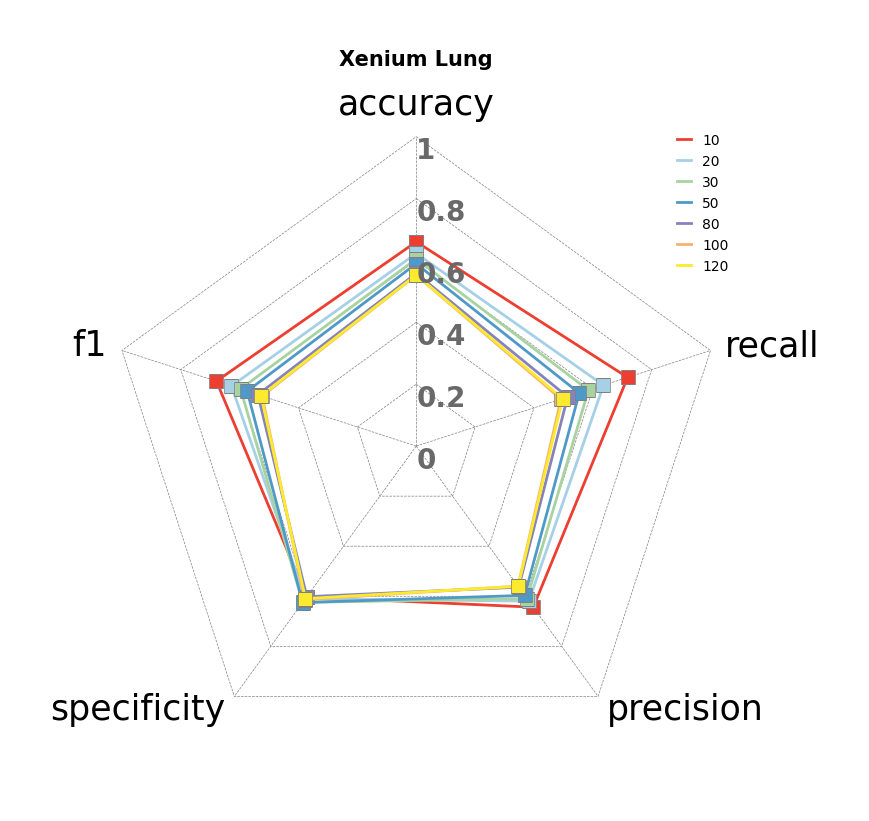

In [60]:
circos = Circos.radar_chart(
    Xe_Lung,
    vmax=1,
    vmin=0,
    bg_color="white",
    marker_size=10,
    circular=False,
    fill=False,
    grid_interval_ratio=0.2,
    cmap={
        str(10): "#EC3E31",
        str(20): "#A6D0E6",
        str(30): "#A8D3A0",
        str(50): "#4F99C9",
        str(80): "#8582BD",
        str(100): "#F8B072",
        str(120): "#FBEA2E",
    },
    label_kws_handler=lambda _: dict(size=25),
    line_kws_handler=lambda _: dict(lw=2, ls="solid"),
    marker_kws_handler=lambda _: dict(marker="s", ec="grey", lw=0.5),
    grid_label_kws=dict(size=20, weight="bold")
)
circos.text("Xenium Lung", r=125, size=15, weight="bold")

# Plot figure & set legend on upper right
fig = circos.plotfig()
_ = circos.ax.legend(loc="upper right")
fig.savefig("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/figures/Xenium_Lung2.png", dpi=300)

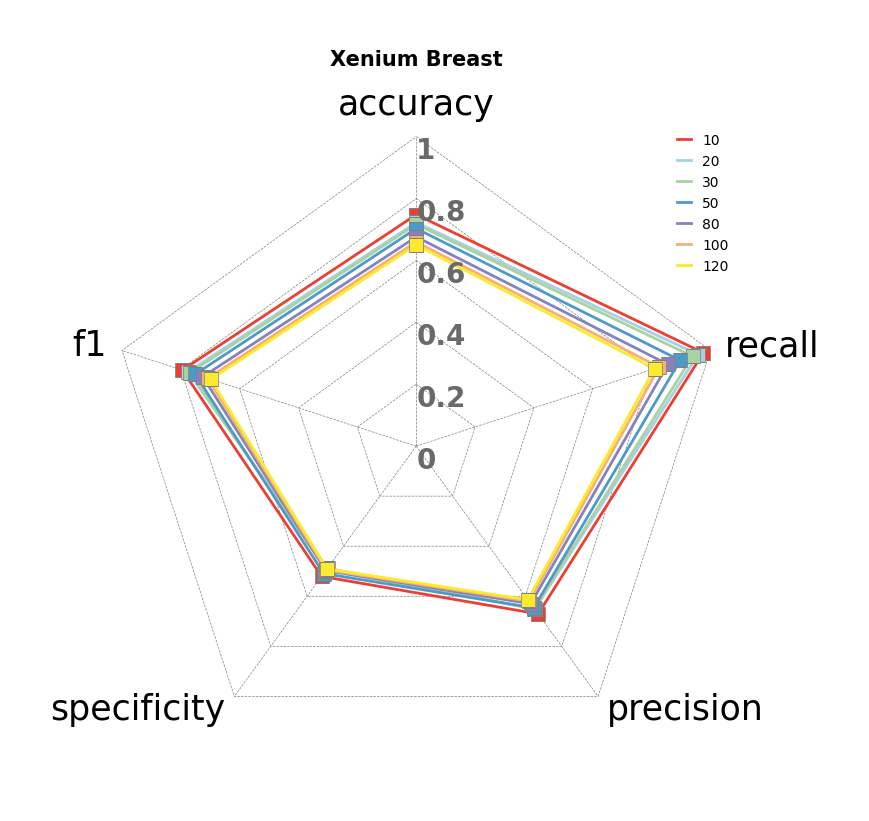

In [51]:
# Initialize Circos instance for radar chart plot
circos = Circos.radar_chart(
    Xe_Breast,
    vmax=1,
    vmin=0,
    bg_color="white",
    marker_size=10,
    circular=False,
    fill=False,
    grid_interval_ratio=0.2,
    cmap={
        str(10): "#EC3E31",
        str(20): "#A6D0E6",
        str(30): "#A8D3A0",
        str(50): "#4F99C9",
        str(80): "#8582BD",
        str(100): "#F8B072",
        str(120): "#FBEA2E",
    },
    label_kws_handler=lambda _: dict(size=25),
    line_kws_handler=lambda _: dict(lw=2, ls="solid"),
    marker_kws_handler=lambda _: dict(marker="s", ec="grey", lw=0.5),
    grid_label_kws=dict(size=20, weight="bold")
)
circos.text("Xenium Breast", r=125, size=15, weight="bold")

# Plot figure & set legend on upper right
fig = circos.plotfig()
_ = circos.ax.legend(loc="upper right")
fig.savefig("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/figures/Xenium_Breast2.png", dpi=300)

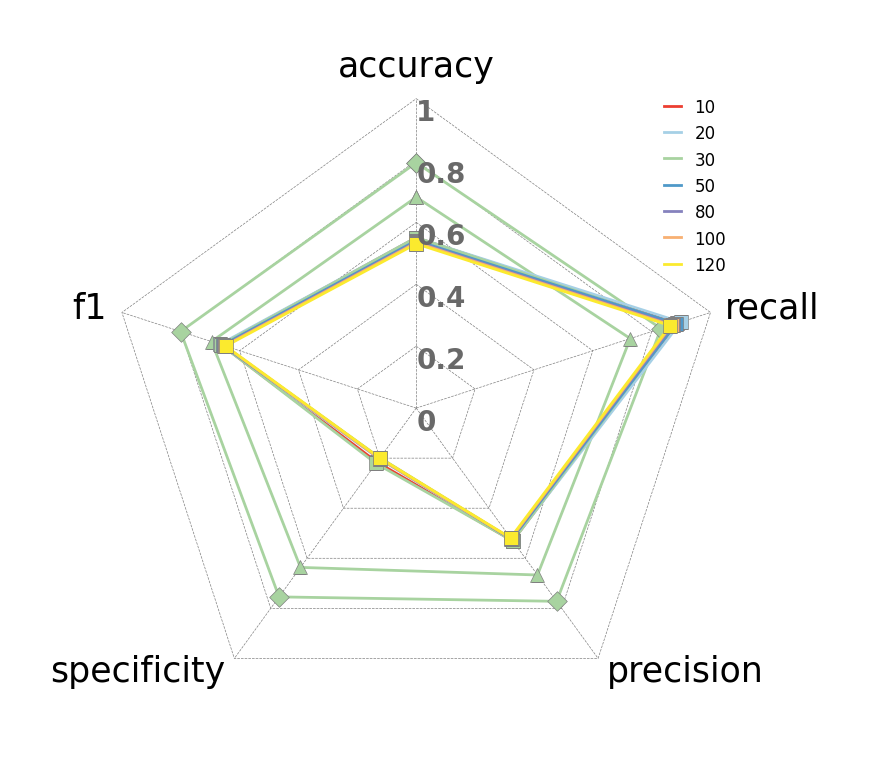

In [36]:
from pycirclize import Circos
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Rename the index of the few-shot data to make it unique
Mf_Breast_few_10k_renamed = Mf_Breast_few_10k.copy()
Mf_Breast_few_10k_renamed.index = ['30_few(10k)']

Mf_Breast_few_100k_renamed = Mf_Breast_few_100k.copy()
Mf_Breast_few_100k_renamed.index = ['30_few(100k)']

# Concatenate both dataframes
combined_data = pd.concat([Mf_Breast_few_10k_renamed, Mf_Breast_few_100k_renamed, Mf_Breast])

# Create single radar chart with both datasets
# Use fill=False to prevent automatic filling for everyone
circos = Circos.radar_chart(
    combined_data,
    vmax=1,
    vmin=0,
    bg_color="white",
    circular=False,
    fill=False,  # We will manually add fill ONLY for 30_few
    grid_interval_ratio=0.2,
    cmap={
        "10": "#EC3E31",
        "20": "#A6D0E6",
        "30": "#A8D3A0",
        "30_few(10k)": "#A8D3A0",
        "30_few(100k)": "#A8D3A0",
        "50": "#4F99C9",
        "80": "#8582BD",
        "100": "#F8B072",
        "120": "#FBEA2E",
    },
    marker_size=10,
    label_kws_handler=lambda _: dict(size=25),
    line_kws_handler=lambda label: dict(
        lw=2,
        ls="solid"
    ),
    marker_kws_handler=lambda label: dict(
        marker={
        "10": "s",
        "20": "s",
        "30": "s",
        "30_few(10k)": "^",
        "30_few(100k)": "D",
        "50": "s",
        "80": "s",
        "100": "s",
        "120": "s",
        }.get(label, "o"),
        ec="grey",
        lw=0.5
    ),
    grid_label_kws=dict(size=20, weight="bold")
)

# Plot figure first
fig = circos.plotfig()
ax = circos.ax

# Title
circos.text("MERFISH Breast", r=125, size=15, weight="bold")

# Custom legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

custom_lines = [
    Line2D([0], [0], color="#EC3E31", lw=2, label="10"),
    Line2D([0], [0], color="#A6D0E6", lw=2, label="20"),
    Line2D([0], [0], color="#A8D3A0", lw=2, label="30"),
    Line2D([0], [0], color="#4F99C9", lw=2, label="50"),
    Line2D([0], [0], color="#8582BD", lw=2, label="80"),
    Line2D([0], [0], color="#F8B072", lw=2, label="100"),
    Line2D([0], [0], color="#FBEA2E", lw=2, label="120"),
]
_ = ax.legend(handles=custom_lines, loc="upper right", fontsize=12)

fig.savefig(
    "/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/figures/MERFISH_breast2.png",
    dpi=300,
    bbox_inches="tight"
)

In [65]:
combined_data

,accuracy,recall,precision,specificity,f1
radius,,,,,
30,0.681818,0.727273,0.666667,0.636364,0.695652
10,0.550781,0.885742,0.530409,0.215820,0.663497
20,0.550856,0.899002,0.529980,0.202709,0.666843
30,0.551093,0.880886,0.530786,0.221299,0.662423
50,0.541179,0.883048,0.524457,0.199310,0.658073
80,0.537168,0.872854,0.522238,0.201483,0.653488
100,0.534507,0.867476,0.520713,0.201537,0.650784
120,0.531017,0.862791,0.518645,0.199244,0.647851


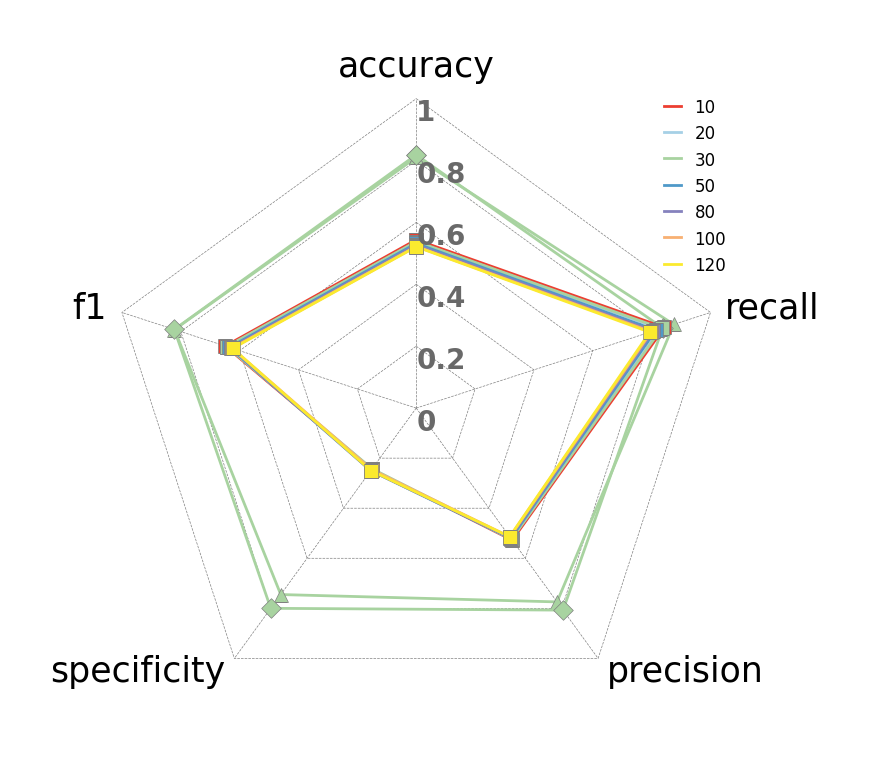

In [37]:


# Rename the index of the few-shot data to make it unique
Mf_Lung_few_10k_renamed = Mf_Lung_few_10k.copy()
Mf_Lung_few_10k_renamed.index = ['30_few(10k)']

Mf_Lung_few_100k_renamed = Mf_Lung_few_100k.copy()
Mf_Lung_few_100k_renamed.index = ['30_few(100k)']

# Concatenate both dataframes
combined_data = pd.concat([Mf_Lung_few_10k_renamed, Mf_Lung_few_100k_renamed, Mf_Lung])

# Create single radar chart with both datasets
# Use fill=False to prevent automatic filling for everyone
# Use fill=False to prevent automatic filling for everyone
circos = Circos.radar_chart(
    combined_data,
    vmax=1,
    vmin=0,
    bg_color="white",
    circular=False,
    fill=False,  # We will manually add fill ONLY for 30_few
    grid_interval_ratio=0.2,
    cmap={
        "10": "#EC3E31",
        "20": "#A6D0E6",
        "30": "#A8D3A0",
        "30_few(10k)": "#A8D3A0",
        "30_few(100k)": "#A8D3A0",
        "50": "#4F99C9",
        "80": "#8582BD",
        "100": "#F8B072",
        "120": "#FBEA2E",
    },
    marker_size=10,
    label_kws_handler=lambda _: dict(size=25),
    line_kws_handler=lambda label: dict(
        lw=2,
        ls="solid"
    ),
    marker_kws_handler=lambda label: dict(
        marker={
        "10": "s",
        "20": "s",
        "30": "s",
        "30_few(10k)": "^",
        "30_few(100k)": "D",
        "50": "s",
        "80": "s",
        "100": "s",
        "120": "s",
        }.get(label, "o"),
        ec="grey",
        lw=0.5
    ),
    grid_label_kws=dict(size=20, weight="bold")
)


# Plot figure first
fig = circos.plotfig()
ax = circos.ax

# Title
circos.text("MERFISH Lung", r=125, size=15, weight="bold")

# Custom legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

custom_lines = [
    Line2D([0], [0], color="#EC3E31", lw=2, label="10"),
    Line2D([0], [0], color="#A6D0E6", lw=2, label="20"),
    Line2D([0], [0], color="#A8D3A0", lw=2, label="30"),
    Line2D([0], [0], color="#4F99C9", lw=2, label="50"),
    Line2D([0], [0], color="#8582BD", lw=2, label="80"),
    Line2D([0], [0], color="#F8B072", lw=2, label="100"),
    Line2D([0], [0], color="#FBEA2E", lw=2, label="120"),
]
_ = ax.legend(handles=custom_lines, loc="upper right", fontsize=12)

fig.savefig("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/figures/MERFISH_Lung2.png", dpi=300)

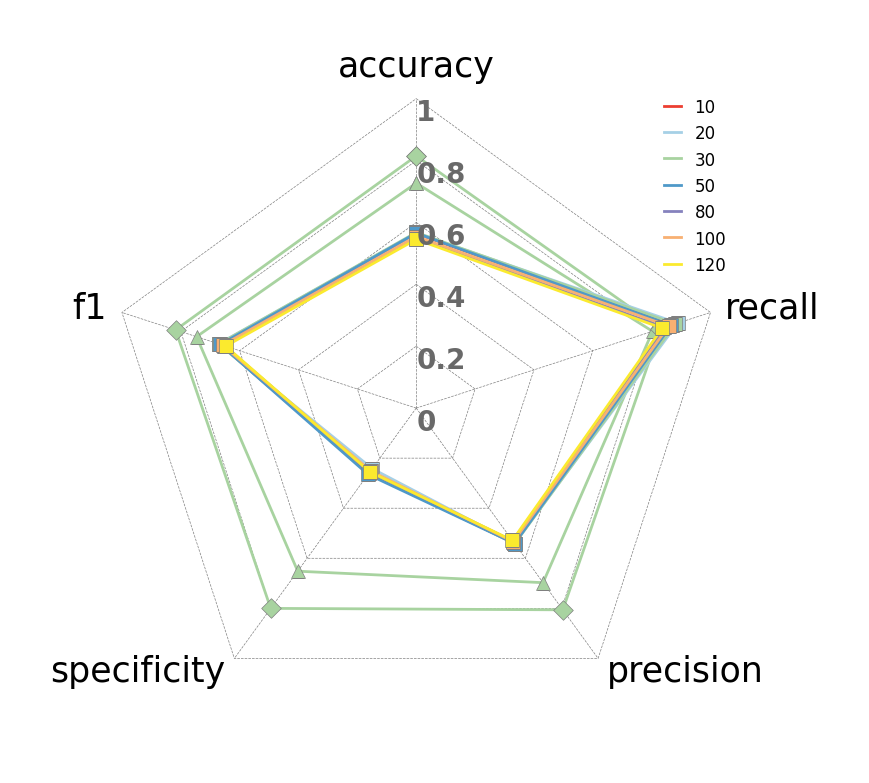

In [38]:

# Rename the index of the few-shot data to make it unique
Mf_Colon_few_10k_renamed = Mf_Colon_few_10k.copy()
Mf_Colon_few_10k_renamed.index = ['30_few(10k)']

Mf_Colon_few_100k_renamed = Mf_Colon_few_100k.copy()
Mf_Colon_few_100k_renamed.index = ['30_few(100k)']

# Concatenate both dataframes
combined_data = pd.concat([Mf_Colon_few_10k_renamed, Mf_Colon_few_100k_renamed, Mf_Colon])

# Create single radar chart with both datasets
# Use fill=False to prevent automatic filling for everyone
# Use fill=False to prevent automatic filling for everyone
circos = Circos.radar_chart(
    combined_data,
    vmax=1,
    vmin=0,
    bg_color="white",
    circular=False,
    fill=False,  # We will manually add fill ONLY for 30_few
    grid_interval_ratio=0.2,
    cmap={
        "10": "#EC3E31",
        "20": "#A6D0E6",
        "30": "#A8D3A0",
        "30_few(10k)": "#A8D3A0",
        "30_few(100k)": "#A8D3A0",
        "50": "#4F99C9",
        "80": "#8582BD",
        "100": "#F8B072",
        "120": "#FBEA2E",
    },
    marker_size=10,
    label_kws_handler=lambda _: dict(size=25),
    line_kws_handler=lambda label: dict(
        lw=2,
        ls="solid"
    ),
    marker_kws_handler=lambda label: dict(
        marker={
        "10": "s",
        "20": "s",
        "30": "s",
        "30_few(10k)": "^",
        "30_few(100k)": "D",
        "50": "s",
        "80": "s",
        "100": "s",
        "120": "s",
        }.get(label, "o"),
        ec="grey",
        lw=0.5
    ),
    grid_label_kws=dict(size=20, weight="bold")
)


# Plot figure first
fig = circos.plotfig()
ax = circos.ax

# Title
circos.text("MERFISH Colon", r=125, size=15, weight="bold")

# Custom legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

custom_lines = [
    Line2D([0], [0], color="#EC3E31", lw=2, label="10"),
    Line2D([0], [0], color="#A6D0E6", lw=2, label="20"),
    Line2D([0], [0], color="#A8D3A0", lw=2, label="30"),
    Line2D([0], [0], color="#4F99C9", lw=2, label="50"),
    Line2D([0], [0], color="#8582BD", lw=2, label="80"),
    Line2D([0], [0], color="#F8B072", lw=2, label="100"),
    Line2D([0], [0], color="#FBEA2E", lw=2, label="120"),
]
_ = ax.legend(handles=custom_lines, loc="upper right", fontsize=12)
fig.savefig("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/figures/MERFISH_Colon2.png", dpi=300)

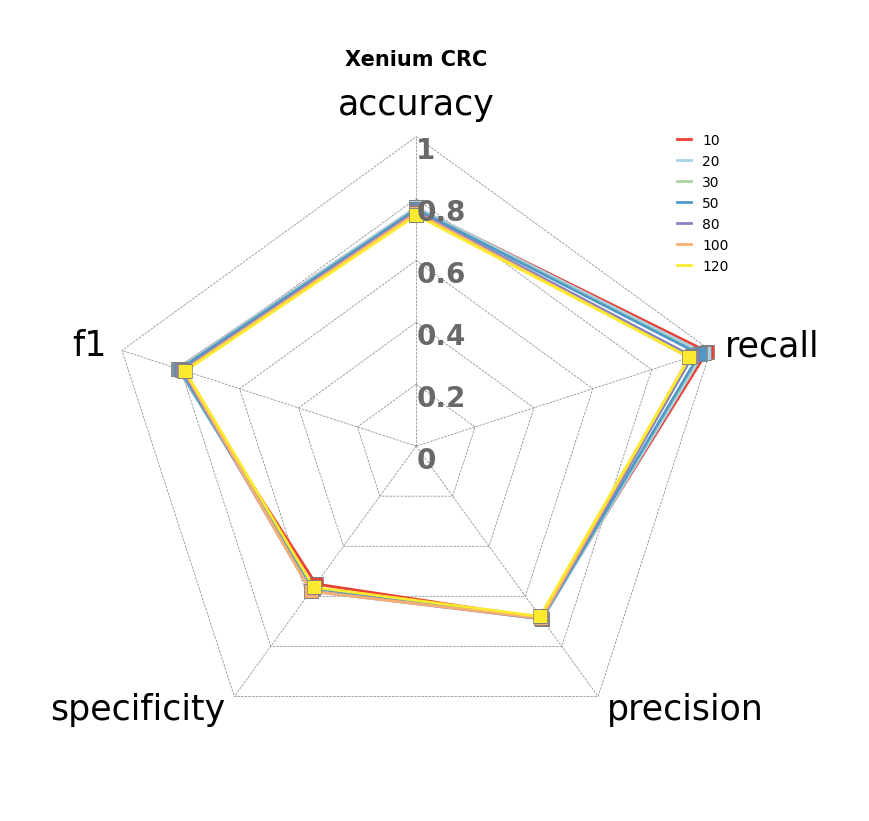

In [50]:

# Initialize Circos instance for radar chart plot
circos = Circos.radar_chart(
    Xe_CRC,
    vmax=1,
    vmin=0,
    bg_color="white",
    marker_size=10,
    circular=False,
    fill=False,
    grid_interval_ratio=0.2,
    cmap={
        str(10): "#EC3E31",
        str(20): "#A6D0E6",
        str(30): "#A8D3A0",
        str(50): "#4F99C9",
        str(80): "#8582BD",
        str(100): "#F8B072",
        str(120): "#FBEA2E",
    },
    label_kws_handler=lambda _: dict(size=25),
    line_kws_handler=lambda _: dict(lw=2, ls="solid"),
    marker_kws_handler=lambda _: dict(marker="s", ec="grey", lw=0.5),
    grid_label_kws=dict(size=20, weight="bold")
)
circos.text("Xenium CRC", r=125, size=15, weight="bold")

# Plot figure & set legend on upper right
fig = circos.plotfig()
_ = circos.ax.legend(loc="upper right")
fig.savefig("/scratch/project_465001820/Spatialformer/downstream/cell_cell_communication/figures/Xenium_CRC2.png", dpi=300)

# Building the zero-shot to predict the cell type colocalization

In [3]:
from datasets import load_from_disk
import sys
sys.path.append("/scratch/project_465001820/Spatialformer/utils")
from utils import *


/scratch/project_465001820/miniconda3/envs/spatialformer_flash_attn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
combined_dataset = load_from_disk("/scratch/project_465001820/Spatialformer/cache/xenium_5k_pandavid_dataset_v2")  
index_path = "/scratch/project_465001820/Spatialformer/data/sample_cell_index"
sample_cell_index = get_index(combined_dataset, save_file = index_path)
sample_name = "THD0008"


In [5]:
combined_dataset

Dataset({
    features: ['Expression', 'Split', 'Gene', 'Cell_Ids', 'Ranked_Gene_Names', 'Full_Tokens', 'Annotations', 'Sample_Names', 'compound_key', 'centroid_x', 'centroid_y', 'Tissues', 'Conditions', 'Rows', 'Cols', 'Data', 'Shape', 'Niche_Annotation', 'Species', 'Assay', 'Cell_id'],
    num_rows: 11625356
})

In [6]:
sample_dataset = combined_dataset.select(list(sample_cell_index[sample_name].values()))


In [9]:
sparse_adj, cell_ids = get_adj(sample_dataset, radius = 30, plot = False, sym = True)

In [10]:
from tqdm import tqdm
def get_ct_contact(sparse_adj, sample_dataset):
    query_key_dict = {}
    sparse_adj = sparse_adj.tocsr() 
    Anns = sample_dataset["Annotations"]
    for cell_id in tqdm(range(sparse_adj.shape[0])):

        query_ct = Anns[cell_id]

        indices_of_one = sparse_adj[[cell_id], :].nonzero()[1]  # Get the column indices of the non-zero entries
        
        # Convert indices to a list of annotations
        if indices_of_one.size > 0:  # Check if any connected cells were found
            key_ct = [Anns[indice] for indice in indices_of_one]
            query_key_dict.setdefault(query_ct, []).extend(key_ct)

    return query_key_dict
        

Get the cell-type colocalization info

In [11]:
#getting the matrix of the cell_type - cell_type contact matrix
query_key_dict = get_ct_contact(sparse_adj, sample_dataset)

100%|██████████| 57012/57012 [00:07<00:00, 7757.82it/s]


Get the cell type - cell type matrix

In [66]:
# Step 1: Identify all unique cell types (queries and keys)
unique_types = set(query_key_dict.keys())


unique_types = sorted(unique_types)  # Sort for consistent indexing

# Step 2: Initialize the matrix
n = len(unique_types)
type_index = {cell_type: i for i, cell_type in enumerate(unique_types)}  # Mapping for index retrieval
adjacency_matrix = np.zeros((n, n), dtype=int)  # Initialize with zeros

# Step 3: Populate the matrix
for query, keys in query_key_dict.items():
    query_index = type_index[query]
    
    for key in keys:
        if key in type_index:  # Ensure the key is in the index mapping
            key_index = type_index[key]
            adjacency_matrix[query_index][key_index] += 1  # Set the connection

# Convert to DataFrame for better visualization
adjacency_df = pd.DataFrame(adjacency_matrix, index=unique_types, columns=unique_types)

# Display the matrix
print(adjacency_df.shape)

(39, 39)


In [67]:
ovlp_ct = {"ATI", "ATII", "Basal", "Ciliated", "NK", "Lymphatic", "Macrophage", "Fibroblast", "B",
          "T", "Mast", "pDC", "SMC"}
ovlp_ct_dict = {"ATI": "AT1", "ATII": "AT2", "Basal": "Basal", "Ciliated": "Ciliated", "NK": "NK cells", "Lymphatic": "Lymphatic/DCs", "Macrophage": "Macrophages", "Fibroblast": "Fibroblasts", "B": "B cells",
          "T": "T-cells", "Mast": "Mast", "pDC": "pDCs", "SMC": "SMCs"}

Filter the adjacency dataframe by its overlapped cell types

In [68]:
ovlp_ct_dict.values()

dict_values(['AT1', 'AT2', 'Basal', 'Ciliated', 'NK cells', 'Lymphatic/DCs', 'Macrophages', 'Fibroblasts', 'B cells', 'T-cells', 'Mast', 'pDCs', 'SMCs'])

In [69]:
adjacency_df = adjacency_df.loc[list(ovlp_ct_dict.values()), list(ovlp_ct_dict.values())]

In [73]:
upper_triangle_mask = np.triu(np.ones(adjacency_df.shape), k=1).astype(bool)
upper_adjacency_df = adjacency_df*upper_triangle_mask

supports = 500
upper_adjacency_df[upper_adjacency_df<supports] = 0
keep_ct = (upper_adjacency_df.sum(axis=0) != 0).values & ~upper_adjacency_df.columns.isin(["not available"])
upper_adjacency_df = upper_adjacency_df.loc[:, keep_ct].loc[keep_ct, :]
# upper_adjacency_df = upper_adjacency_df.loc[:, ].loc[~["not available"], :]

In [81]:
# adjacency_df
supports = 500
adjacency_df[adjacency_df<supports] = 0
keep_ct = (adjacency_df.sum(axis=0) != 0).values & ~adjacency_df.columns.isin(["not available"])
adjacency_df = adjacency_df.loc[:, keep_ct].loc[keep_ct, :]

In [75]:
adjacency_df

,AT1,AT2,Basal,Ciliated,NK cells,Lymphatic/DCs,Macrophages,Fibroblasts,T-cells,Mast,SMCs
AT1,570,2818,0,0,519,0,737,1098,497,0,308
AT2,2818,15584,0,0,2316,412,3834,5154,2542,949,1228
Basal,0,0,1448,776,0,0,0,0,346,382,0
Ciliated,0,0,776,3354,0,0,0,0,232,416,0
NK cells,519,2316,0,0,782,0,918,1211,607,0,363
Lymphatic/DCs,0,412,0,0,0,1342,505,1117,464,219,332
Macrophages,737,3834,0,0,918,505,2740,3708,1923,779,1105
Fibroblasts,1098,5154,0,0,1211,1117,3708,6616,2863,1347,2865
T-cells,497,2542,346,232,607,464,1923,2863,2150,672,819
Mast,0,949,382,416,0,219,779,1347,672,732,499


# visualization of the circular plot with cell-cell colocalization

In [123]:
# adjacency_df
# adjacency_df.columns
# new_columns = np.array(['AT1', 'AT2', 'Ad FBs', 'Al FBs', 'Arteriole', 'Basal',
#        'Ciliated', 'DCs', 'Diff Ciliated', 'FABP4+ Mac',
#        'Fib', 'Int Mac', 'Lip',
#        'Lym/DCs', 'MUC5B+', 'Mac', 'Mast', 'NK cells',
#        'Peri FBs', 'Plasma', 'Pro Endo',
#        'Pro Epi', 'Pro Lym',
#        'Pro Mes', 'Pro Myeloid', 'SMCs',
#        'SPP1+ Mac', 'T-cells', 'Venous', 'aCap', 'gCap'])
# new_columns = new_columns[keep_ct]
# adjacency_df.columns = new_columns
# adjacency_df.index = new_columns

In [126]:
adjacency_df.loc["T-cells",:]

AT1                             0
AT2                          2542
Adventitial FBs                 0
Alveolar FBs                 1811
Arteriole                     621
Basal                           0
Ciliated                        0
DCs                             0
Differentiating Ciliated        0
FABP4+ Macrophages            803
Fibroblasts                  2863
Interstitial Macrophages     3452
Lymphatic/DCs                   0
MUC5B+                          0
Macrophages                  1923
Mast                          672
NK cells                      607
Plasma                          0
Proliferating Endothelial       0
Proliferating Epithelial      927
Proliferating Lymphoid          0
Proliferating Mesenchymal       0
Proliferating Myeloid           0
SMCs                          819
SPP1+ Macrophages               0
T-cells                      2150
Venous                        699
aCap                          527
gCap                         5156
Name: T-cells,

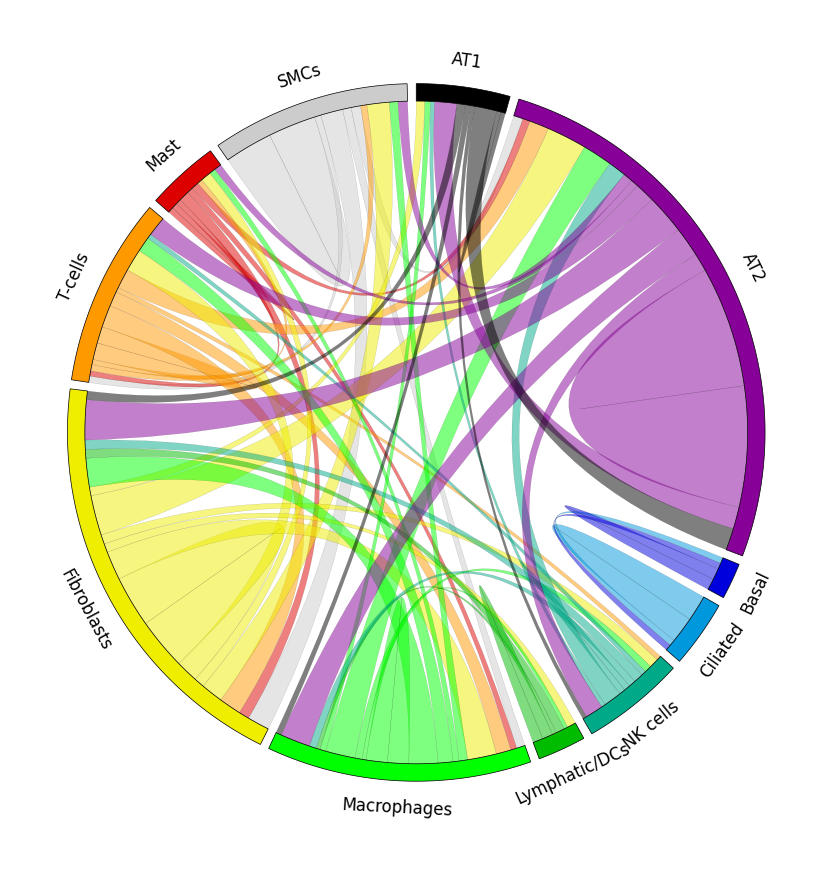

In [82]:
from pycirclize import Circos
import pandas as pd

import matplotlib.pyplot as plt
from pycirclize import Circos  # Replace with the actual library import

# Initialize the Circos plot
circos = Circos.initialize_from_matrix(
    adjacency_df,
    space=1.5,
    r_lim=(95, 100),
    cmap="nipy_spectral",
#     ticks_interval=5,

    label_kws=dict(size=12, rotation=60),
    link_kws=dict(ec="black", lw=0.1, direction=0),
)
# dict(r=94, size=12, color="white")
fig = circos.plotfig()

plt.show()

circos.savefig("./figures/ct_colocalization.png", dpi=300)
# circos.savefig("./figures/ct_colocalization.png")

# Getting the ground truth of the cellular composition

In [18]:

def get_cell_comp(sparse_adj, sample_dataset, prob):
    cell_composition = {}
    sparse_adj = sparse_adj.tocsr() 
    Anns = sample_dataset["Annotations"]
    unique_types = sorted(Anns)  # Sort for consistent indexing
    nb_dict = {ct: 0 for ct in unique_types}  
    
    for cell_id in tqdm(range(sparse_adj.shape[0])):

        indices_of_one = sparse_adj[[cell_id], :].nonzero()[1]  # Get the column indices of the non-zero entries
        
        # Convert indices to a list of annotations
        if indices_of_one.size > 0:  # Check if any connected cells were found
            for indice in indices_of_one:
                nb_dict[Anns[indice]] += 1
            if prob:
                ct_num = np.sum(list(nb_dict.values()))
                for ct in nb_dict.keys():
                    nb_dict[ct] = nb_dict[ct]/ct_num
            
            cell_composition[cell_id] = nb_dict
            nb_dict = {ct: 0 for ct in unique_types}  


    return cell_composition

def get_pred_comp(sparse_adj, sample_dataset, left_indexs, right_indexs, preds, prob):
    Anns = sample_dataset["Annotations"]
    unique_types = sorted(np.unique(Anns))  # Sort for consistent indexing
    pred_cell_composition = {}
    
    # Using np.unique to get unique left indices
    unique_left_indexs = np.unique(left_indexs)
#     print("Unique left indices:", unique_left_indexs)
    
    for left_index in unique_left_indexs:
        nb_dict = {ct: 0 for ct in unique_types}  # Initialize counts for this left_index
        left_pos = np.where(left_indexs == left_index)[0]
#         print(left_pos)
        indices_of_one = right_indexs[left_pos]
        preds_of_one = preds[left_pos]
#         print(indices_of_one, preds_of_one)
        # Iterate through the indices and predictions
        for indice, pred in zip(indices_of_one, preds_of_one):
            if pred == 1:  # Only include the predicted indices to calculate the ratio
                nb_dict[Anns[indice]] += 1
        
        if prob:
            ct_num = np.sum(list(nb_dict.values()))
            # Normalize counts if ct_num is greater than zero
            if ct_num > 0:
                for ct in nb_dict.keys():
                    nb_dict[ct] /= ct_num
        
        pred_cell_composition[left_index] = nb_dict  # Store the result for this left_index

    return pred_cell_composition
        

Get the cell x cell matrix within a certain radius

In [12]:
sparse_adj, cell_ids = get_adj(sample_dataset, radius = 30, plot = False, sym = True)

Getting the ground-truth cellular composition

In [13]:
cell_composition = get_cell_comp(sparse_adj, sample_dataset, prob=False)

100%|██████████| 57012/57012 [01:57<00:00, 486.46it/s]


Getting the predicted cellular composition (only select the positive prediction) single slide prediction(30um)

In [14]:
import pickle
all_left_indexs = pickle.load(open(f"/scratch/project_465001027/Spatialformer/data/all_left_indexs_20250108_204807_singleslide.pkl", "rb"))
all_right_indexs = pickle.load(open(f"/scratch/project_465001027/Spatialformer/data/all_right_indexs_20250108_204807_singleslide.pkl", "rb"))
all_preds = pickle.load(open("/scratch/project_465001027/Spatialformer/data/all_preds_20250108_204807_singleslide.pkl", "rb"))

#only fetch the positive pairs
all_pos_left_index = []
all_pos_right_index = []
all_pos_pred = []
neg = []
pos = []
sparse_adj = sparse_adj.tocsr() 
for i,j,pred in zip(all_left_indexs, all_right_indexs, all_preds):
    value = sparse_adj[i,j]
    if value == 0:
        neg.append((i,j))
    else:
        all_pos_left_index.append(i)
        all_pos_right_index.append(j)
        pos.append((i,j))                                       
        all_pos_pred.append(pred)

all_pos_left_index = np.array(all_pos_left_index)
all_pos_right_index = np.array(all_pos_right_index)
all_pos_pred = np.array(all_pos_pred)
single_pred_cell_composition = get_pred_comp(sparse_adj, sample_dataset, all_pos_left_index, all_pos_right_index, all_pos_pred, prob = False)

Getting the lung slides prediction(30um)

In [15]:
import pickle
all_left_indexs = pickle.load(open(f"/scratch/project_465001027/Spatialformer/data/all_left_indexs_20250108_213849_alllungslides.pkl", "rb"))
all_right_indexs = pickle.load(open(f"/scratch/project_465001027/Spatialformer/data/all_right_indexs_20250108_213849_alllungslides.pkl", "rb"))
all_preds = pickle.load(open("/scratch/project_465001027/Spatialformer/data/all_preds_20250108_213849_alllungslides.pkl", "rb"))

#only fetch the positive pairs
all_pos_left_index = []
all_pos_right_index = []
all_pos_pred = []
neg = []
pos = []
sparse_adj = sparse_adj.tocsr() 
for i,j,pred in zip(all_left_indexs, all_right_indexs, all_preds):
    value = sparse_adj[i,j]
    if value == 0:
        neg.append((i,j))
    else:
        all_pos_left_index.append(i)
        all_pos_right_index.append(j)
        pos.append((i,j))                                       
        all_pos_pred.append(pred)

all_pos_left_index = np.array(all_pos_left_index)
all_pos_right_index = np.array(all_pos_right_index)
all_pos_pred = np.array(all_pos_pred)
alllung_pred_cell_composition = get_pred_comp(sparse_adj, sample_dataset, all_pos_left_index, all_pos_right_index, all_pos_pred, prob = False)

In [147]:
all_preds.sum()

12526

In [139]:
len(all_right_indexs)

17132

In [140]:
len(all_pos_left_index)*2

17132

In [141]:
len(neg)

8566

Getting the all 61 slides prediction(30um)

In [16]:
import pickle
all_left_indexs = pickle.load(open(f"/scratch/project_465001027/Spatialformer/data/all_left_indexs_20250108_213644_all61slides.pkl", "rb"))
all_right_indexs = pickle.load(open(f"/scratch/project_465001027/Spatialformer/data/all_right_indexs_20250108_213644_all61slides.pkl", "rb"))
all_preds = pickle.load(open("/scratch/project_465001027/Spatialformer/data/all_preds_20250108_213644_all61slides.pkl", "rb"))

#only fetch the positive pairs
all_pos_left_index = []
all_pos_right_index = []
all_pos_pred = []
neg = []
pos = []
sparse_adj = sparse_adj.tocsr() 
for i,j,pred in zip(all_left_indexs, all_right_indexs, all_preds):
    value = sparse_adj[i,j]
    if value == 0:
        neg.append((i,j))
    else:
        all_pos_left_index.append(i)
        all_pos_right_index.append(j)
        pos.append((i,j))                                       
        all_pos_pred.append(pred)

all_pos_left_index = np.array(all_pos_left_index)
all_pos_right_index = np.array(all_pos_right_index)
all_pos_pred = np.array(all_pos_pred)
allslides_pred_cell_composition = get_pred_comp(sparse_adj, sample_dataset, all_pos_left_index, all_pos_right_index, all_pos_pred, prob = False)

In [145]:
all_preds.sum()

11907

In [143]:
all_right_indexs

array([10847, 55318, 26297, ..., 50164,  7168,  1096])

In [144]:
len(all_pos_left_index)

8566

# Plot Recall for each cell type

In [19]:
unique_left_indexs = np.unique(all_pos_left_index)
Anns = sample_dataset["Annotations"]
unique_types = sorted(np.unique(Anns)) # Sort for consistent indexing
tp = 0
total_t = 0
ct_tp = {}
ct_lung_tp = {}
ct_allslide_tp = {}
ct_total = {}
recall_ct = {}
for query in unique_left_indexs:
    gt_ct_dict = cell_composition[query]
    pred_ct_dict = single_pred_cell_composition[query]
    lungslide_pred_ct_dict = alllung_pred_cell_composition[query]
    allslide_pred_ct_dict = allslides_pred_cell_composition[query]
    for ct, gt_ct_num in gt_ct_dict.items():
        pred_ct_num = pred_ct_dict[ct]
        lung_pred_ct_num = lungslide_pred_ct_dict[ct]
        allslide_pred_ct_num = allslide_pred_ct_dict[ct]
        ct_total.setdefault(ct, []).append(gt_ct_num)
        ct_tp.setdefault(ct, []).append(pred_ct_num)
        ct_lung_tp.setdefault(ct, []).append(lung_pred_ct_num)
        ct_allslide_tp.setdefault(ct, []).append(allslide_pred_ct_num)
singleslide_ratio_dict = {}
lungslide_ratio_dict = {}
allslide_ratio_dict = {}
for ct in unique_types:
    supports = np.sum(ct_total[ct])
#     singleslide_ratio_dict[f"{ct}_({supports})"] = np.sum(ct_tp[ct])/np.sum(ct_total[ct])
#     lungslide_ratio_dict[f"{ct}_({supports})"] = np.sum(ct_lung_tp[ct])/np.sum(ct_total[ct])
#     allslide_ratio_dict[f"{ct}_({supports})"] = np.sum(ct_allslide_tp[ct])/np.sum(ct_total[ct])
    singleslide_ratio_dict[f"{ct}"] = np.sum(ct_tp[ct])/np.sum(ct_total[ct])
    lungslide_ratio_dict[f"{ct}"] = np.sum(ct_lung_tp[ct])/np.sum(ct_total[ct])
    allslide_ratio_dict[f"{ct}"] = np.sum(ct_allslide_tp[ct])/np.sum(ct_total[ct])
    
    
     

/tmp/ipykernel_101537/2401287560.py:32: RuntimeWarning: invalid value encountered in long_scalars
  singleslide_ratio_dict[f"{ct}"] = np.sum(ct_tp[ct])/np.sum(ct_total[ct])
/tmp/ipykernel_101537/2401287560.py:33: RuntimeWarning: invalid value encountered in long_scalars
  lungslide_ratio_dict[f"{ct}"] = np.sum(ct_lung_tp[ct])/np.sum(ct_total[ct])
/tmp/ipykernel_101537/2401287560.py:34: RuntimeWarning: invalid value encountered in long_scalars
  allslide_ratio_dict[f"{ct}"] = np.sum(ct_allslide_tp[ct])/np.sum(ct_total[ct])


Visualization of the line plot

In [20]:
df_single = pd.DataFrame(list(singleslide_ratio_dict.items()), columns=['Cell Type', 'Recall'])
df_single["Model"] = "Fine_tune(one slide)"
df_lungslides = pd.DataFrame(list(lungslide_ratio_dict.items()), columns=['Cell Type', 'Recall'])
df_lungslides["Model"] = "Fine_tune(lung slides)"
df_allslides = pd.DataFrame(list(allslide_ratio_dict.items()), columns=['Cell Type', 'Recall'])
df_allslides["Model"] = "Zero_shot(61 slides)"
#concate
df_all = pd.concat([df_single, df_lungslides, df_allslides])

In [21]:
df_all

,Cell Type,Recall,Model
0,AT1,0.496689,Fine_tune(one slide)
1,AT2,0.469751,Fine_tune(one slide)
2,Activated FBs,1.000000,Fine_tune(one slide)
3,Adventitial FBs,0.600000,Fine_tune(one slide)
4,Alveolar FBs,0.532290,Fine_tune(one slide)
...,...,...,...
34,Venous,0.825581,Zero_shot(61 slides)
35,aCap,0.899497,Zero_shot(61 slides)
36,gCap,0.886014,Zero_shot(61 slides)
37,not available,0.868217,Zero_shot(61 slides)


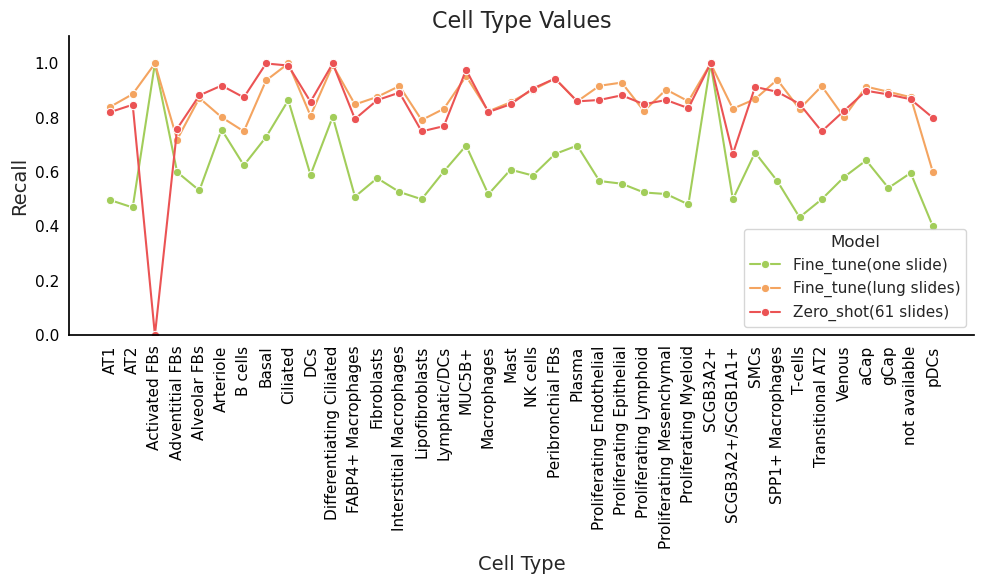

In [22]:

import seaborn as sns
# Convert to DataFrame
# df = pd.DataFrame(list(ratio_dict.items()), columns=['Cell Type', 'Recall'])
dot_color = ["#A2CD5A", "#F4A460", "#EB5354"]

# Flatten axes array for easy iteration
# axes = axes.flatten()
# metrics = ["test_accuracy", "test_recall", "test_precision", "test_specificity", "test_f1"]

# Loop through metrics to create individual plots
# for ax, metric in zip(axes, metrics):
#     sns.lineplot(data=all_stats, x='radius', y=metric, marker='o', ax=ax, linewidth=1.5, hue='Model', palette=dot_color)

# Drop NaN values if necessary
df_all.dropna(inplace=True)

# Set the aesthetics
sns.set(style='whitegrid')

# Create the line plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_all, x='Cell Type', y='Recall', marker='o', color="#EB5354", palette=dot_color, hue='Model')

# Title and labels
plt.title('Cell Type Values', fontsize=16)
plt.xlabel('Cell Type', fontsize=14)
plt.ylabel('Recall', fontsize=14)
plt.xticks(rotation=90)  # Rotate x labels for better readability
plt.ylim(0, 1.1)  # Set y-axis limits
plt.grid(False)

# Drop the top and right frame
sns.despine()
# plt.legend(title='Model', loc='upper center', bbox_to_anchor=(1, 1.75), ncol=1)  # Adjusts legend position
# Set x and y axis color to black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')

# Set tick parameters for both axes to black
plt.tick_params(axis='x', length=4, colors='black')  # Set x-tick marks color
plt.tick_params(axis='y', length=4, colors='black')  # Set y-tick marks color

# Show the plot
plt.tight_layout()
plt.savefig("/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/figures/cell_type_recall.png")
plt.show()

In [34]:
np.sum(ct_total["B cells"])

2

In [26]:
np.sum(ct_tp["B cells"])

2

In [35]:
ratio_dict

{'AT1_(102)': 0.5882352941176471,
 'AT2_(419)': 0.47255369928400953,
 'Activated FBs_(0)': nan,
 'Adventitial FBs_(23)': 0.5217391304347826,
 'Alveolar FBs_(292)': 0.5924657534246576,
 'Arteriole_(68)': 0.6764705882352942,
 'B cells_(2)': 1.0,
 'Basal_(13)': 0.6923076923076923,
 'Ciliated_(35)': 0.8,
 'DCs_(26)': 0.5,
 'Differentiating Ciliated_(50)': 0.88,
 'FABP4+ Macrophages_(177)': 0.4689265536723164,
 'Fibroblasts_(302)': 0.6059602649006622,
 'Interstitial Macrophages_(568)': 0.6038732394366197,
 'KRT5-/KRT17+_(0)': nan,
 'Lipofibroblasts_(10)': 0.4,
 'Lymphatic/DCs_(32)': 0.53125,
 'MUC5B+_(17)': 0.7058823529411765,
 'Macrophages_(209)': 0.5454545454545454,
 'Mast_(70)': 0.5714285714285714,
 'NK cells_(105)': 0.5714285714285714,
 'Peribronchial FBs_(14)': 0.8571428571428571,
 'Plasma_(17)': 0.7058823529411765,
 'Proliferating Endothelial_(57)': 0.6666666666666666,
 'Proliferating Epithelial_(153)': 0.5294117647058824,
 'Proliferating Lymphoid_(17)': 0.5294117647058824,
 'Prolifer

In [36]:
import numpy as np

def kl_divergence(p, q):
    """Compute the KL divergence D(p || q)."""
    return np.sum(np.where(p != 0, p * np.log(p / q), 0))

def jsd(p, q):
    """Compute the Jensen-Shannon Divergence between two probability distributions."""
    # Normalize p and q to ensure they are valid distributions
    p = p / np.sum(p)
    q = q / np.sum(q)
    
    # Compute M
    m = 0.5 * (p + q)
    
    # Compute JSD
    return 0.5 * kl_divergence(p, m) + 0.5 * kl_divergence(q, m)

def count_JSD(P_counts, Q_counts):
    
    # Compute probability distributions
    P = P_counts / np.sum(P_counts)
    Q = Q_counts / np.sum(Q_counts)
    # Compute JSD
    jsd_score = jsd(P, Q)
    print("Jensen-Shannon Divergence (JSD) score:", jsd_score)
    return jsd_score

In [37]:
#Calculating JSD for each cell type
ct_tp
ct_total
ct_jsd = {}
for ct,gt_dis in ct_total.items():
    pred_dis = ct_tp[ct]
    jsd_score = count_JSD(pred_dis, gt_dis)
    ct_jsd[ct] = jsd_score

Jensen-Shannon Divergence (JSD) score: 0.15833846745848185
Jensen-Shannon Divergence (JSD) score: 0.1526267461759138
Jensen-Shannon Divergence (JSD) score: nan
Jensen-Shannon Divergence (JSD) score: 0.14927172104602832
Jensen-Shannon Divergence (JSD) score: 0.12427208957507743
Jensen-Shannon Divergence (JSD) score: 0.10082917055334373
Jensen-Shannon Divergence (JSD) score: 0.0
Jensen-Shannon Divergence (JSD) score: 0.12070213706544539
Jensen-Shannon Divergence (JSD) score: 0.022907511204795714
Jensen-Shannon Divergence (JSD) score: 0.21576155433883568
Jensen-Shannon Divergence (JSD) score: 0.02899176626538672
Jensen-Shannon Divergence (JSD) score: 0.191719858793017
Jensen-Shannon Divergence (JSD) score: 0.10544054994193343
Jensen-Shannon Divergence (JSD) score: 0.08315077766108536
Jensen-Shannon Divergence (JSD) score: nan
Jensen-Shannon Divergence (JSD) score: 0.27435846855026524
Jensen-Shannon Divergence (JSD) score: 0.18596546351106302
Jensen-Shannon Divergence (JSD) score: 0.029840

/tmp/ipykernel_109377/52140257.py:5: RuntimeWarning: invalid value encountered in true_divide
  return np.sum(np.where(p != 0, p * np.log(p / q), 0))
/tmp/ipykernel_109377/52140257.py:5: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.where(p != 0, p * np.log(p / q), 0))
/tmp/ipykernel_109377/52140257.py:5: RuntimeWarning: invalid value encountered in multiply
  return np.sum(np.where(p != 0, p * np.log(p / q), 0))
/tmp/ipykernel_109377/52140257.py:22: RuntimeWarning: invalid value encountered in true_divide
  P = P_counts / np.sum(P_counts)
/tmp/ipykernel_109377/52140257.py:23: RuntimeWarning: invalid value encountered in true_divide
  Q = Q_counts / np.sum(Q_counts)


In [38]:
df = pd.DataFrame(list(ct_jsd.items()), columns=['Cell Type', 'JSD'])

In [39]:
df.dropna(inplace=True)
df

,Cell Type,JSD
0,AT1,0.158338
1,AT2,0.152627
3,Adventitial FBs,0.149272
4,Alveolar FBs,0.124272
5,Arteriole,0.100829
6,B cells,0.000000
7,Basal,0.120702
8,Ciliated,0.022908
9,DCs,0.215762
10,Differentiating Ciliated,0.028992


Visualization of the cell type level JSD

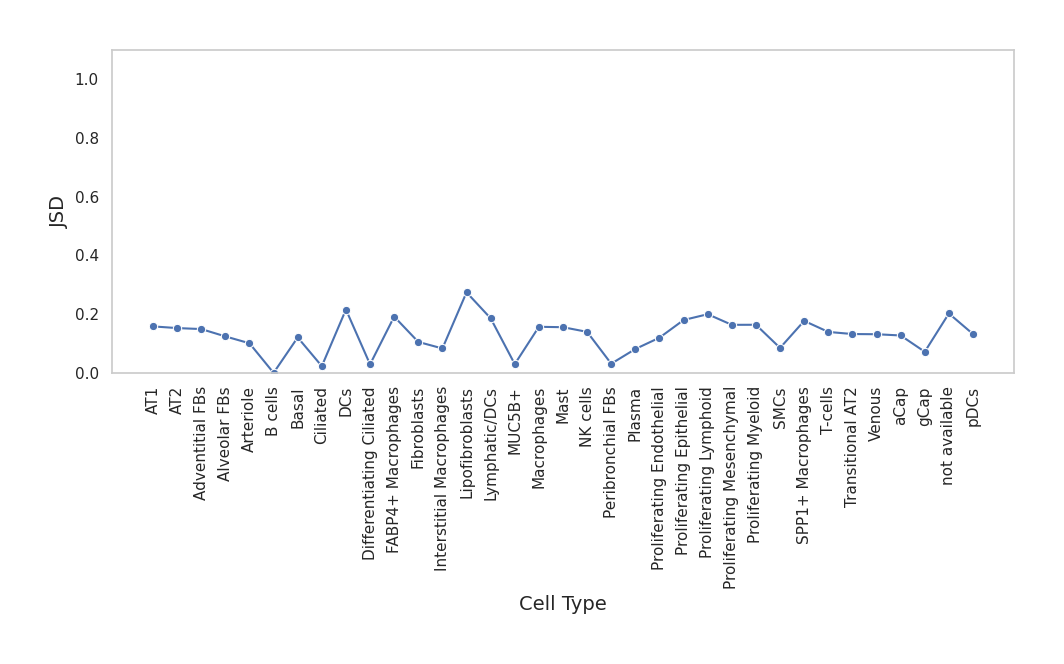

In [43]:
import seaborn as sns
# Convert to DataFrame
df = pd.DataFrame(list(ct_jsd.items()), columns=['Cell Type', 'JSD'])

# Drop NaN values if necessary
df.dropna(inplace=True)

# Set the aesthetics
# sns.set(style='whitegrid')
# Create the line plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Cell Type', y='JSD', marker='o')

# Title and labels
plt.xlabel('Cell Type', fontsize=14)
plt.ylabel('JSD', fontsize=14)
plt.xticks(rotation=90)  # Rotate x labels for better readability
plt.ylim(0, 1.1)  # Set y-axis limits
plt.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

# Adding the PCA as the baseline

In [61]:
import numpy as np

# Set the random seed for reproducibility
# np.random.seed(42)

# Generate two random vectors of a specified size (for example, 10 elements)
vector_size = 10

vec1 = np.random.rand(vector_size)
vec2 = np.random.rand(vector_size)

# Function to calculate cosine similarity
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    if norm_vec1 == 0 or norm_vec2 == 0:
        return 0.0
    return dot_product / (norm_vec1 * norm_vec2)

# Calculate cosine similarity
similarity = cosine_similarity(vec1, vec2)

# Print the results
print("Vector 1:", vec1)
print("Vector 2:", vec2)
print("Cosine Similarity:", similarity)

Vector 1: [0.87367711 0.98408347 0.76827341 0.41776678 0.421357   0.7375823
 0.23877715 0.11047411 0.35462216 0.28723899]
Vector 2: [0.29630812 0.23360775 0.04209319 0.01787393 0.98772239 0.42777313
 0.38432665 0.67964728 0.21825389 0.94996118]
Cosine Similarity: 0.5618676102906609
